## How to find out whether the variables (predictors) are linearly related ?

That’s an important question — because before you apply Linear Regression, you must first verify whether the relationship between your variables (predictor(s) and response) is actually linear.

Step 1: Visual Inspection (Scatter Plot)
If you have one independent variable (X) and one dependent variable (Y):

Plot a scatter plot of Y vs. X

If the points roughly follow a straight-line trend (either upward or downward), the relationship is linear.

If they form a curve (U-shape, inverted U, exponential, etc.), the relationship is non-linear.

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot of X vs Y")
plt.show()

Interpretation:

    - Straight line trend → Linear relationship
    - Curved or random pattern → Non-linear or no relationship

Step 2. Correlation Coefficient (for one variable)

If you have one predictor:

Compute Pearson’s correlation coefficient (r)

Formula conceptually:
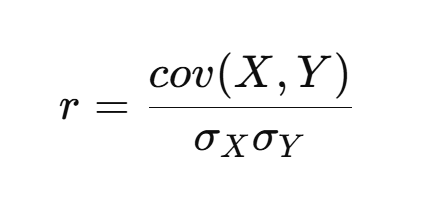



In [ ]:
import numpy as np
np.corrcoef(X, y)[0, 1]

Interpretation:

|r| close to 1 → Strong linear relationship

|r| close to 0 → Weak or no linear relationship
⚠️ But correlation ≠ causation — and it only captures linear association.

Step 3. Residual Plot (for fitted linear model)

After fitting a linear regression model:

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X.reshape(-1,1), y)
y_pred = model.predict(X.reshape(-1,1))

plt.scatter(X, y - y_pred)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("X")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Interpretation:

Residuals scattered randomly around 0 → ✅ Linear model appropriate

Residuals show a pattern (curve, funnel, etc.) → ❌ Non-linearity or heteroscedasticity

Step 4. Partial Residual Plots (for multiple regression)

When you have multiple predictors, visualize the relationship between each predictor and the response after controlling for others using partial regression plots.

In Python:

In [2]:
import statsmodels.api as sm
sm.graphics.plot_partregress_grid(model)
plt.show()

NameError: name 'model' is not defined

Step 5. Use Statistical Tests (Optional)

You can also use Ramsey’s RESET test for linearity:

Null hypothesis (H₀): Model is linear

If p-value < 0.05 → reject H₀ → model may be non-linear

In Python (using statsmodels):

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset

model = sm.OLS(y, sm.add_constant(X)).fit()
linear_reset(model, power=2, use_f=True)


Step 6. Try Transformations if Non-linear

If the relationship is not linear, try transforming variables:

Logarithm (log(X), log(Y))

Square root (sqrt(X))

Polynomial terms (X², X³, etc.)

Interaction terms (X₁ * X₂)

Then recheck the scatter plot or residuals.


| Method                  | Works with          | What to Look For                    |   |            |
| ----------------------- | ------------------- | ----------------------------------- | - | ---------- |
| Scatter Plot            | 1 predictor         | Linear trend                        |   |            |
| Pearson Correlation     | 1 predictor         |                                     | r | close to 1 |
| Residual Plot           | Any                 | Random residuals around 0           |   |            |
| Partial Regression Plot | Multiple predictors | Linear trend after adjustment       |   |            |
| Ramsey RESET Test       | Any                 | Significant p-value = non-linearity |   |            |
